# Notebook 4: Encode Clinical Notes with ClinicalBERT

## Objective
Transform discharge note text into fixed-size numerical embeddings using ClinicalBERT, a BERT model pre-trained on clinical text. This creates a dense vector representation of clinical notes suitable for downstream machine learning.

## Input Data
- `labeled_admissions_with_notes.csv` (311,459 admissions from Notebook 2)
- Sample: 10,000 admissions (stratified by readmission status)

## Model
- **ClinicalBERT** (`emilyalsentzer/Bio_ClinicalBERT`)
  - Pre-trained on MIMIC-III clinical notes
  - BERT-base architecture (110M parameters)
  - Output: 768-dimensional embeddings

## Process

### 1. **Sampling Strategy**
- Create stratified sample of 10K admissions
- Preserve readmission class balance (~20% positive rate)
- Enables faster prototyping before scaling to full dataset

### 2. **Text Chunking**
- Problem: Clinical notes are long (avg ~10K characters, ~2.5K tokens)
- BERT limit: 512 tokens per input
- Solution: Split notes into overlapping chunks
  - Max length: 512 tokens
  - Overlap: 50 tokens (preserves context across boundaries)
  - Example: 10K char note → ~5 chunks

### 3. **Encoding Each Chunk**
```
Text chunk → Tokenization → ClinicalBERT → [CLS] token embedding (768-dim)
```
- Use `[CLS]` token embedding as chunk representation
- CLS token = BERT's learned summary of the text
- Process chunks in batches of 32 for efficiency

### 4. **Aggregation to Admission-Level**
- Multiple chunk embeddings → Mean pooling → Single admission embedding
- Mean pooling averages information across all chunks
- Output: One 768-dim vector per admission (regardless of note length)

### 5. **GPU Acceleration**
- A100 GPU enables fast encoding (~5-10 minutes for 10K notes)
- Batch processing optimizes GPU utilization

## Output
- `note_embeddings_sample_10k.npz` - Compressed numpy array (10,000 × 768)
- `hadm_id_mapping_sample_10k.csv` - Maps embeddings to admission IDs
- File size: ~60 MB compressed

## Key Findings
- Average chunks per note: ~5.4
- Notes requiring chunking: ~85% (most notes exceed 512 tokens)
- Encoding time: ~8 minutes on A100 GPU
- Each admission now represented as 768-dimensional vector

## Why This Approach?
1. **Chunking with overlap** - Preserves context at chunk boundaries
2. **CLS token** - Standard BERT practice for sequence representation
3. **Mean pooling** - Aggregates information democratically across chunks
4. **Pre-computed embeddings** - Save time; don't re-encode for every experiment

## Encoding vs Concatenation
We encode notes SEPARATELY from tabular data because:
- BERT is optimized for text, not structured data
- Allows modular architecture (can swap encoders)
- Standard practice in multimodal medical ML

## Next Step
Notebook 5 will engineer tabular features from structured EHR data (demographics, diagnoses, medications).
Notebook 6 will encode temporal event sequences.
Notebook 7 will fuse all modalities (text + tabular + events) for final prediction model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Verify GPU is available
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected - encoding will be very slow")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.47 GB


In [3]:
# Install transformers and other required packages
!pip install transformers accelerate -q

print("Libraries installed")

Libraries installed


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import gc

# Settings
pd.set_option('display.max_columns', 50)
torch.set_grad_enabled(False)  # Inference mode - saves memory

print("Libraries imported")

Libraries imported


In [5]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')
EMBEDDINGS_DIR = OUTPUT_DIR / 'embeddings'

# Create embeddings directory
EMBEDDINGS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output
Embeddings directory: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings


In [6]:
# Load admissions with notes from Notebook 2
print("Loading admissions with notes...")
notes_df = pd.read_csv(OUTPUT_DIR / 'labeled_admissions_with_notes.csv')

print(f"\nLoaded {len(notes_df):,} admissions with notes")
print(f"Shape: {notes_df.shape}")
print(f"\nColumns: {notes_df.columns.tolist()}")

Loading admissions with notes...

Loaded 311,459 admissions with notes
Shape: (311459, 19)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'note_id', 'charttime', 'storetime', 'text']


In [7]:
# Create a stratified sample to maintain class balance
print("\nCreating stratified sample of 10K admissions...")

SAMPLE_SIZE = 10000

# Sample while preserving readmission rate
sample_df = notes_df.groupby('readmitted_30day', group_keys=False).apply(
    lambda x: x.sample(n=int(SAMPLE_SIZE * len(x) / len(notes_df)), random_state=42)
).reset_index(drop=True)

print(f"\nSample size: {len(sample_df):,}")
print(f"\nReadmission distribution in sample:")
print(sample_df['readmitted_30day'].value_counts())
print(f"\nReadmission rate:")
print(f"  Original: {notes_df['readmitted_30day'].mean()*100:.2f}%")
print(f"  Sample: {sample_df['readmitted_30day'].mean()*100:.2f}%")

# Save sample for reproducibility
sample_df.to_csv(OUTPUT_DIR / 'sample_10k_admissions_with_notes.csv', index=False)
print(f"\nSample saved for reproducibility")


Creating stratified sample of 10K admissions...

Sample size: 9,999

Readmission distribution in sample:
readmitted_30day
0    7935
1    2064
Name: count, dtype: int64

Readmission rate:
  Original: 20.65%
  Sample: 20.64%


/tmp/ipython-input-3861231133.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = notes_df.groupby('readmitted_30day', group_keys=False).apply(



Sample saved for reproducibility



Analyzing note lengths...

Note length statistics (characters):
count     9999.000000
mean     10344.034003
std       4281.143998
min       1685.000000
25%       7354.000000
50%       9665.000000
75%      12545.000000
max      50460.000000
Name: note_length, dtype: float64


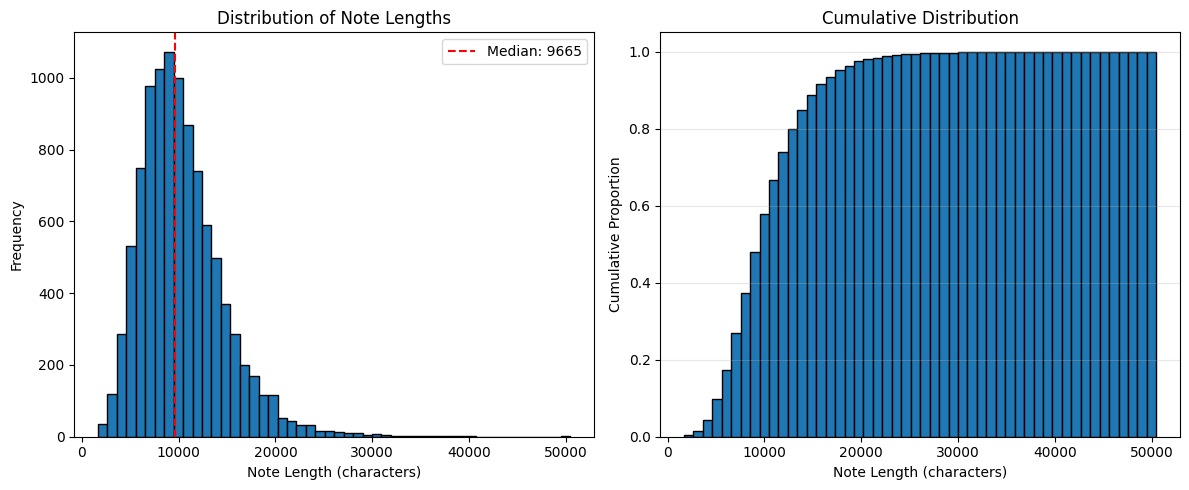


Estimated tokens (chars/4):
count     9999.000000
mean      2586.008501
std       1070.286000
min        421.250000
25%       1838.500000
50%       2416.250000
75%       3136.250000
max      12615.000000
Name: estimated_tokens, dtype: float64


In [8]:
# Analyze note lengths to understand chunking needs
print("\nAnalyzing note lengths...")

sample_df['note_length'] = sample_df['text'].str.len()

print("\nNote length statistics (characters):")
print(sample_df['note_length'].describe())

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sample_df['note_length'], bins=50, edgecolor='black')
plt.xlabel('Note Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Note Lengths')
plt.axvline(sample_df['note_length'].median(), color='red', linestyle='--', label=f'Median: {sample_df["note_length"].median():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(sample_df['note_length'], bins=50, edgecolor='black', cumulative=True, density=True)
plt.xlabel('Note Length (characters)')
plt.ylabel('Cumulative Proportion')
plt.title('Cumulative Distribution')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'note_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Estimate tokens (rough approximation: 1 token ≈ 4 characters)
sample_df['estimated_tokens'] = sample_df['note_length'] / 4
print(f"\nEstimated tokens (chars/4):")
print(sample_df['estimated_tokens'].describe())

In [9]:
# Load ClinicalBERT model and tokenizer
print("\nLoading ClinicalBERT model...")
print("Model: emilyalsentzer/Bio_ClinicalBERT")

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"\nModel loaded on: {device}")
print(f"Embedding dimension: {model.config.hidden_size}")


Loading ClinicalBERT model...
Model: emilyalsentzer/Bio_ClinicalBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]


Model loaded on: cuda
Embedding dimension: 768


In [10]:
# Test encoding on a single note to verify everything works
print("\nTesting encoding on a single note...")

# Get first note
test_note = sample_df['text'].iloc[0]
print(f"\nTest note length: {len(test_note)} characters")
print(f"First 300 characters:\n{test_note[:300]}...\n")

# Tokenize
tokens = tokenizer(
    test_note,
    max_length=512,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
).to(device)

print(f"Tokenized shape: {tokens['input_ids'].shape}")

# Encode
with torch.no_grad():
    outputs = model(**tokens)
    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token

print(f"Embedding shape: {embedding.shape}")
print(f"Embedding sample (first 10 values): {embedding[0, :10]}")
print("\nTest successful - ready for batch encoding")


Testing encoding on a single note...

Test note length: 12186 characters
First 300 characters:
 
Name:  ___                   Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: NEUROLOGY
 
Allergies: 
Hydrochlorothiazide
 
Attending: ___
 
Chief Complaint:
code stroke
 
Major Surgical or Invasive Procedure:
NONE
 
His...

Tokenized shape: torch.Size([1, 512])
Embedding shape: (1, 768)
Embedding sample (first 10 values): [-0.03013737  0.30829096 -0.50603145  0.04126022  0.03794878  0.14712851
  0.10183962  0.19163157  0.42712063 -0.17564796]

Test successful - ready for batch encoding


## Helper Functions

In [11]:
# Function to chunk long notes into 512-token segments with overlap
def chunk_text(text, tokenizer, max_length=512, overlap=50):
    """
    Split text into overlapping chunks that fit within max_length tokens.

    Args:
        text: Input text string
        tokenizer: HuggingFace tokenizer
        max_length: Maximum tokens per chunk
        overlap: Number of overlapping tokens between chunks

    Returns:
        List of text chunks
    """
    # Tokenize the full text
    tokens = tokenizer.encode(text, add_special_tokens=False)

    # If text fits in one chunk, return as is
    if len(tokens) <= max_length - 2:  # -2 for [CLS] and [SEP]
        return [text]

    # Create overlapping chunks
    chunks = []
    stride = max_length - overlap - 2  # Account for special tokens

    for i in range(0, len(tokens), stride):
        chunk_tokens = tokens[i:i + max_length - 2]
        chunk_text = tokenizer.decode(chunk_tokens)
        chunks.append(chunk_text)

        # Stop if we've covered the whole text
        if i + max_length - 2 >= len(tokens):
            break

    return chunks

# Test on long note
test_note = sample_df['text'].iloc[0]
test_chunks = chunk_text(test_note, tokenizer, max_length=512, overlap=50)
print(f"Test note: {len(test_note)} characters")
print(f"Number of chunks created: {len(test_chunks)}")
print(f"First chunk length: {len(test_chunks[0])} characters")
print(f"Last chunk length: {len(test_chunks[-1])} characters")

Test note: 12186 characters
Number of chunks created: 8
First chunk length: 1840 characters
Last chunk length: 1664 characters


In [12]:
def encode_chunks(chunks, model, tokenizer, device, batch_size=32):
    """
    Encode a list of text chunks using BERT.

    Args:
        chunks: List of text chunks
        model: BERT model
        tokenizer: Tokenizer
        device: torch device
        batch_size: Batch size for encoding

    Returns:
        numpy array of shape (num_chunks, hidden_size)
    """
    embeddings = []

    # Process in batches
    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i + batch_size]

        # Tokenize batch
        tokens = tokenizer(
            batch_chunks,
            max_length=512,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        ).to(device)

        # Encode
        with torch.no_grad():
            outputs = model(**tokens)
            # Use CLS token embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# Test encoding function
test_embeddings = encode_chunks(test_chunks, model, tokenizer, device, batch_size=8)
print(f"\nTest encoding results:")
print(f"Number of chunks: {len(test_chunks)}")
print(f"Embeddings shape: {test_embeddings.shape}")
print(f"Embedding dimension: {test_embeddings.shape[1]}")


Test encoding results:
Number of chunks: 8
Embeddings shape: (8, 768)
Embedding dimension: 768


In [13]:
def aggregate_embeddings(chunk_embeddings, method='mean'):
    """
    Aggregate multiple chunk embeddings into a single embedding.

    Args:
        chunk_embeddings: numpy array of shape (num_chunks, hidden_size)
        method: Aggregation method ('mean', 'max', or 'first')

    Returns:
        Single embedding vector of shape (hidden_size,)
    """
    if method == 'mean':
        return np.mean(chunk_embeddings, axis=0)
    elif method == 'max':
        return np.max(chunk_embeddings, axis=0)
    elif method == 'first':
        return chunk_embeddings[0]
    else:
        raise ValueError(f"Unknown aggregation method: {method}")

# Test aggregation
aggregated = aggregate_embeddings(test_embeddings, method='mean')
print(f"Aggregated embedding shape: {aggregated.shape}")
print(f"Sample values: {aggregated[:10]}")

Aggregated embedding shape: (768,)
Sample values: [-0.05318229  0.11787289 -0.3686601   0.19026999 -0.21452029 -0.00204959
  0.281527    0.06229039  0.30794895 -0.1812419 ]


In [14]:
# Encode all notes in the sample
print(f"\nEncoding {len(sample_df):,} notes with ClinicalBERT...")
print("This will take approximately 5-10 minutes on A100...\n")

all_embeddings = []
hadm_ids = []
num_chunks_list = []

# Batch size for encoding
BATCH_SIZE = 32

# Process each note
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Encoding notes"):
    hadm_id = row['hadm_id']
    note_text = row['text']

    # Chunk the note
    chunks = chunk_text(note_text, tokenizer, max_length=512, overlap=50)
    num_chunks_list.append(len(chunks))

    # Encode chunks
    chunk_embeddings = encode_chunks(chunks, model, tokenizer, device, batch_size=BATCH_SIZE)

    # Aggregate to admission-level
    admission_embedding = aggregate_embeddings(chunk_embeddings, method='mean')

    all_embeddings.append(admission_embedding)
    hadm_ids.append(hadm_id)

    # Free memory periodically
    if (idx + 1) % 1000 == 0:
        gc.collect()
        torch.cuda.empty_cache()

# Convert to numpy array
embeddings_array = np.vstack(all_embeddings)

print(f"\nEncoding complete!")
print(f"Final embeddings shape: {embeddings_array.shape}")
print(f"Expected: ({len(sample_df)}, 768)")


Encoding 9,999 notes with ClinicalBERT...
This will take approximately 5-10 minutes on A100...



Encoding notes: 100%|██████████| 9999/9999 [10:27<00:00, 15.93it/s]


Encoding complete!
Final embeddings shape: (9999, 768)
Expected: (9999, 768)



Chunking statistics:
Notes requiring chunking: 9,996 (100.0%)

Chunks per note:
count    9999.000000
mean        6.928893
std         2.800538
min         1.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        37.000000
dtype: float64


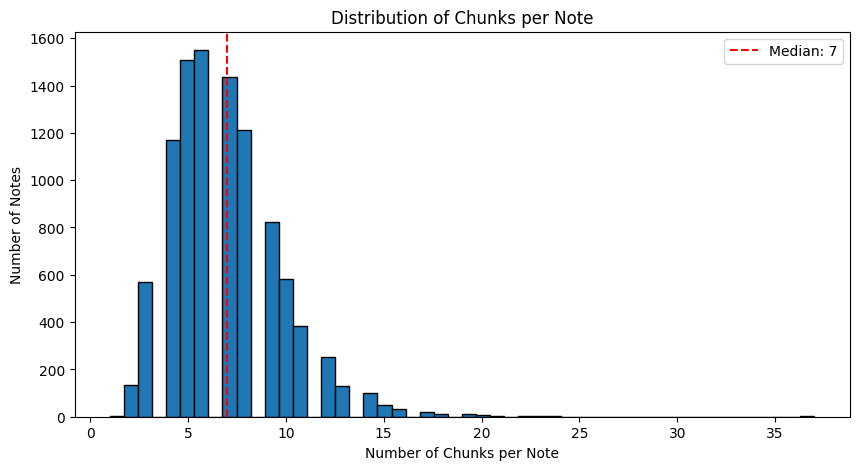

In [15]:
# Analyze how many chunks were needed per note
chunks_stats = pd.Series(num_chunks_list)

print("\nChunking statistics:")
print(f"Notes requiring chunking: {(chunks_stats > 1).sum():,} ({(chunks_stats > 1).sum()/len(chunks_stats)*100:.1f}%)")
print(f"\nChunks per note:")
print(chunks_stats.describe())

plt.figure(figsize=(10, 5))
plt.hist(chunks_stats, bins=50, edgecolor='black')
plt.xlabel('Number of Chunks per Note')
plt.ylabel('Number of Notes')
plt.title('Distribution of Chunks per Note')
plt.axvline(chunks_stats.median(), color='red', linestyle='--', label=f'Median: {chunks_stats.median():.0f}')
plt.legend()
plt.savefig(EMBEDDINGS_DIR / 'chunks_per_note_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save embeddings as compressed numpy array
embeddings_file = EMBEDDINGS_DIR / 'note_embeddings_sample_10k.npz'
mapping_file = EMBEDDINGS_DIR / 'hadm_id_mapping_sample_10k.csv'

# Save embeddings
np.savez_compressed(
    embeddings_file,
    embeddings=embeddings_array,
    hadm_ids=np.array(hadm_ids)
)

# Save mapping separately for easier loading
mapping_df = pd.DataFrame({
    'hadm_id': hadm_ids,
    'embedding_index': range(len(hadm_ids))
})
mapping_df.to_csv(mapping_file, index=False)

print(f"\nSaved embeddings to: {embeddings_file}")
print(f"Saved mapping to: {mapping_file}")
print(f"Embeddings file size: {embeddings_file.stat().st_size / (1024*1024):.2f} MB")


Saved embeddings to: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/note_embeddings_sample_10k.npz
Saved mapping to: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/hadm_id_mapping_sample_10k.csv
Embeddings file size: 27.18 MB


In [17]:
# Load and verify
print("\nVerifying saved embeddings...")

loaded = np.load(embeddings_file)
loaded_embeddings = loaded['embeddings']
loaded_hadm_ids = loaded['hadm_ids']

print(f"Loaded embeddings shape: {loaded_embeddings.shape}")
print(f"Loaded hadm_ids length: {len(loaded_hadm_ids)}")

# Check they match
assert np.array_equal(loaded_embeddings, embeddings_array), "Embeddings don't match!"
assert np.array_equal(loaded_hadm_ids, hadm_ids), "hadm_ids don't match!"

print("\nVerification passed - embeddings saved correctly")

# Show sample
print(f"\nSample embedding for hadm_id {loaded_hadm_ids[0]}:")
print(f"First 10 values: {loaded_embeddings[0, :10]}")


Verifying saved embeddings...
Loaded embeddings shape: (9999, 768)
Loaded hadm_ids length: 9999

Verification passed - embeddings saved correctly

Sample embedding for hadm_id 20111014:
First 10 values: [-0.05318229  0.11787289 -0.3686601   0.19026999 -0.21452029 -0.00204959
  0.281527    0.06229039  0.30794895 -0.1812419 ]


In [18]:
print("\n" + "="*60)
print("NOTEBOOK 4 COMPLETE: CLINICAL NOTES ENCODED")
print("="*60)

print(f"\nSummary:")
print(f"  Notes encoded: {len(sample_df):,}")
print(f"  Embedding dimension: {embeddings_array.shape[1]}")
print(f"  Average chunks per note: {np.mean(num_chunks_list):.1f}")
print(f"  Notes requiring >1 chunk: {(chunks_stats > 1).sum():,} ({(chunks_stats > 1).sum()/len(chunks_stats)*100:.1f}%)")

print(f"\nOutputs:")
print(f"  Embeddings: {embeddings_file}")
print(f"  Mapping: {mapping_file}")

print(f"\nNext steps:")
print(f"  - Notebook 5: Engineer tabular features")
print(f"  - Notebook 6: Encode temporal event sequences")
print(f"  - Notebook 7: Multimodal fusion and classification")

# Clean up GPU memory
del model
torch.cuda.empty_cache()
gc.collect()
print("\nGPU memory cleared")


NOTEBOOK 4 COMPLETE: CLINICAL NOTES ENCODED

Summary:
  Notes encoded: 9,999
  Embedding dimension: 768
  Average chunks per note: 6.9
  Notes requiring >1 chunk: 9,996 (100.0%)

Outputs:
  Embeddings: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/note_embeddings_sample_10k.npz
  Mapping: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/hadm_id_mapping_sample_10k.csv

Next steps:
  - Notebook 5: Engineer tabular features
  - Notebook 6: Encode temporal event sequences
  - Notebook 7: Multimodal fusion and classification

GPU memory cleared
